Cell 0 – Import Libraries

This block imports the essential libraries required for data analysis and machine learning. pandas is used for data manipulation, numpy for numerical operations, while matplotlib and seaborn are used for data visualization. These libraries provide the foundation for performing EDA and building models.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Cell 1 – Load Dataset

The dataset is loaded using pd.read_csv() into a DataFrame. The head() function displays the first few rows, helping to understand the structure, column names, and sample values of the dataset.

In [5]:
df = pd.read_csv(r"C:\Users\DARSH\Downloads\WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Cell 2 – Dataset Information

The info() function provides a summary of the dataset, including data types, number of non-null values, and memory usage. This step helps identify missing values and understand whether columns are numerical or categorical.

The describe() function generates statistical insights such as mean, standard deviation, minimum, maximum, and quartiles. This helps in understanding the distribution and variability of features like alcohol, acidity, and pH.



In [6]:
df.info()
df.describe()
df['quality'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

Cell 3- Null values

This step uses isnull().sum() to check for missing values in each column. It ensures the dataset is clean or helps decide if preprocessing steps like dropping or filling values are needed.

In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Cell 4 -Converting Target Variable into Binary Classification

To simplify the prediction problem, the wine quality scores are converted into a binary classification (good vs bad quality).

In [8]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

Cell 5 - Defining Features and Target Variable

To prepare the dataset for machine learning, the features (inputs) and target (output) are separated.



In [9]:
X = df.drop('quality', axis=1)
y = df['quality']

Cell 6 -Train-Test Split

To evaluate the model’s performance effectively, the dataset is divided into training and testing sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Cell 7 -Training the Random Forest Model

A Random Forest Classifier is initialized and trained on the dataset to predict wine quality.

In [11]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Cell 8 -Making Predictions with the Model

After training the Random Forest model, predictions are generated on the test dataset.

In [12]:
y_pred = model.predict(X_test)

Cell 9 -Model Evaluation using Accuracy and Classification Report

The performance of the classification model is evaluated using accuracy and a detailed classification report.

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7991266375545851
              precision    recall  f1-score   support

           0       0.76      0.79      0.78       102
           1       0.83      0.80      0.82       127

    accuracy                           0.80       229
   macro avg       0.80      0.80      0.80       229
weighted avg       0.80      0.80      0.80       229



Cell 10 -Correlation Heatmap

This block visualizes the correlation between numerical features using a heatmap.

plt.figure(figsize=(12, 8)) sets the size of the plot for better readability.

df.corr() computes the correlation matrix, showing relationships between variables.

sns.heatmap() displays the correlations using colors:

Red indicates positive correlation

Blue indicates negative correlation

annot=True shows correlation values inside each cell.

fmt=".2f" limits values to 2 decimal places.

cmap="coolwarm" improves visual contrast.

linewidths=0.5 adds separation lines between cells.

plt.title() adds a title to the plot.

plt.xticks(rotation=45) rotates x-axis labels for clarity.

plt.yticks(rotation=0) keeps y-axis labels straight.

plt.show() displays the final heatmap.

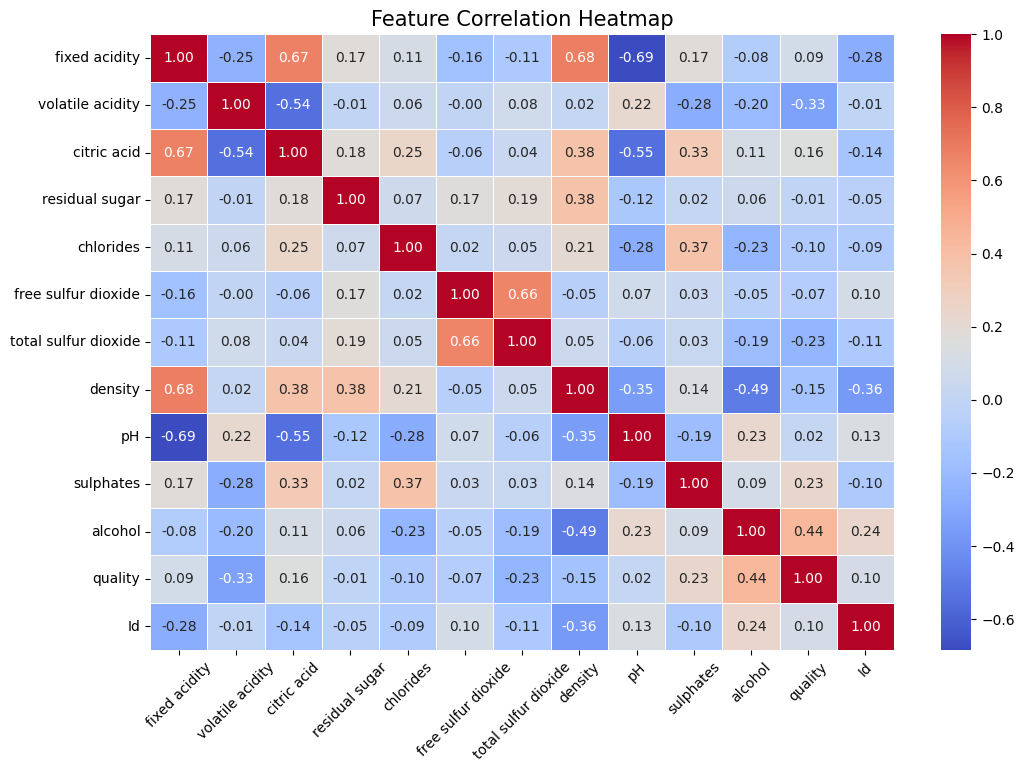

In [15]:
plt.figure(figsize=(12, 8))  # bigger size

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",        # show only 2 decimal places
    cmap="coolwarm",  # better color contrast
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()